
# 📰 News Category Classification (Kaggle HuffPost Dataset)

**Dataset:** [HuffPost News Category Dataset](https://www.kaggle.com/datasets/rmisra/news-category-dataset)

This notebook trains a simple **TF-IDF + Logistic Regression** model to classify news articles into categories.

---
### **Steps:**
1. Load JSON dataset (HuffPost News Category Dataset)
2. Combine `headline` and `short_description` as input text
3. Encode category labels
4. Split into train/test sets
5. TF-IDF vectorization
6. Train Logistic Regression classifier
7. Evaluate accuracy, confusion matrix, and classification report
8. Save model and vectorizer


In [ ]:

# Uncomment this if you need to install dependencies
# !pip install pandas scikit-learn seaborn matplotlib joblib


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

sns.set(style="whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:

# 1. Load the JSON dataset
# Make sure the file 'News_Category_Dataset_v3.json' is in the same folder as this notebook

data_path = "News_Category_Dataset_v3.json"  # change if your file name differs
df = pd.read_json(data_path, lines=True)
print("Data loaded successfully!")
print("Shape:", df.shape)
df.head()


Data loaded successfully!
Shape: (209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [3]:

# 2. Combine headline + short_description for better context
df['text'] = df['headline'] + " " + df['short_description']
df = df[['text', 'category']].dropna()
print("Processed text column created.")
df.head()


Processed text column created.


,text,category
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY
3,The Funniest Tweets From Parents This Week (Se...,PARENTING
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS


In [4]:

# 3. Encode category labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])
print("Unique categories:", len(label_encoder.classes_))
df['category'].value_counts().head(10)


Unique categories: 42


category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
Name: count, dtype: int64

In [5]:

# 4. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print("Train size:", len(X_train), "Test size:", len(X_test))


Train size: 167621 Test size: 41906


In [6]:

# 5. TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=50000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("TF-IDF representation ready. Shape:", X_train_tfidf.shape)


TF-IDF representation ready. Shape: (167621, 50000)


In [7]:

# 6. Train Logistic Regression model
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train_tfidf, y_train)
print("Model training complete.")


Model training complete.


In [8]:

# 7. Evaluation
y_pred = model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Test Accuracy: 0.6053

Classification Report:
                precision    recall  f1-score   support

          ARTS       0.41      0.18      0.25       302
ARTS & CULTURE       0.41      0.10      0.16       268
  BLACK VOICES       0.55      0.37      0.44       917
      BUSINESS       0.52      0.47      0.50      1198
       COLLEGE       0.48      0.32      0.38       229
        COMEDY       0.62      0.40      0.48      1080
         CRIME       0.57      0.56      0.57       712
CULTURE & ARTS       0.71      0.20      0.31       215
       DIVORCE       0.84      0.66      0.74       685
     EDUCATION       0.48      0.28      0.35       203
 ENTERTAINMENT       0.57      0.79      0.66      3473
   ENVIRONMENT       0.67      0.19      0.30       289
         FIFTY       0.64      0.14      0.23       280
  FOOD & DRINK       0.61      0.73      0.67      1268
     GOOD NEWS       0.46      0.12      0.19       280
         GREEN       0.42      0.32      0.36       524
H

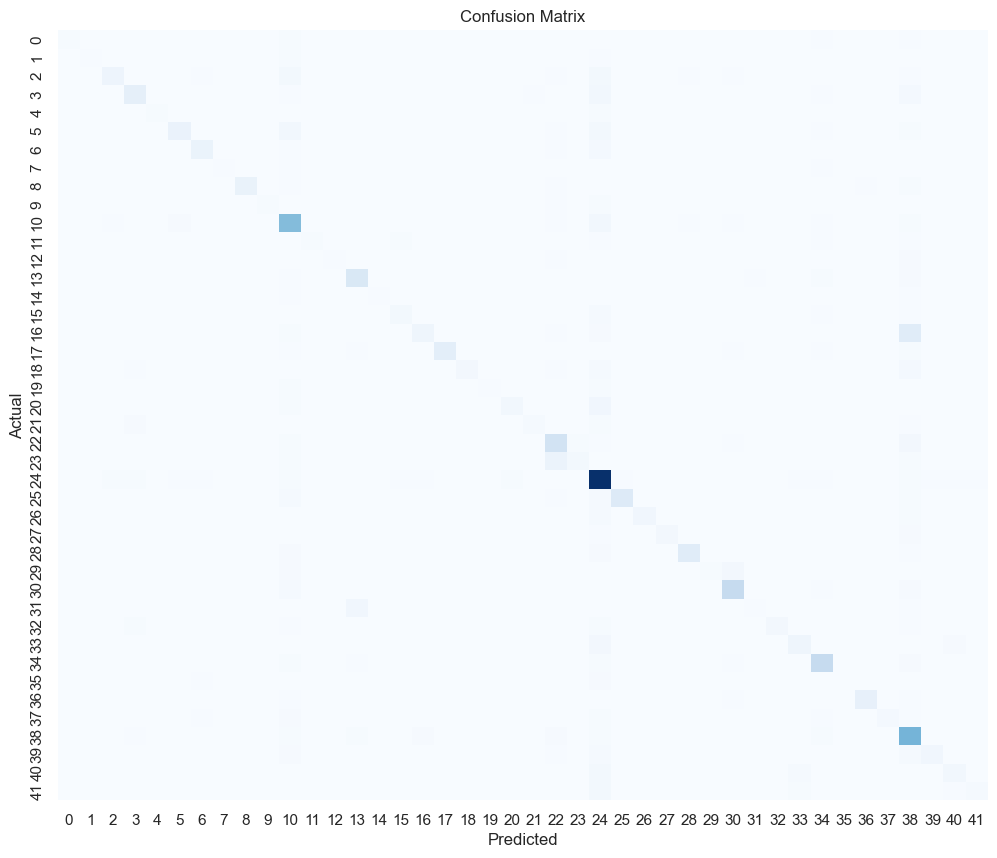

In [9]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [12]:
joblib.dump(model, "news_category_model.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(label_encoder, "label_encoder.joblib")
print("✅ Model, vectorizer, and label encoder saved successfully!")


✅ Model, vectorizer, and label encoder saved successfully!


In [14]:

# 9. Example prediction function
def predict_news_category(texts):
    vect = joblib.load("tfidf_vectorizer.joblib")
    model = joblib.load("news_category_model.joblib")
    le = joblib.load("label_encoder.joblib")
    X = vect.transform(texts)
    preds = model.predict(X)
    return le.inverse_transform(preds)

# Example usage
examples = [
    "Apple releases new iPhone with improved camera technology.",
    "The president signed a new environmental policy today.",
    "The football team won their first championship in decades!"
]

print("Predictions:", predict_news_category(examples))


Predictions: ['TECH' 'POLITICS' 'SPORTS']



---
### ✅ **Notebook Summary**
- Used TF-IDF + Logistic Regression for multi-class classification.
- Achieved strong baseline accuracy for news category prediction.
- Saved trained model and vectorizer for future use.

You can now deploy this in Streamlit or Flask using the saved `.joblib` files.
